In [1]:
# Install YOLOv9 via ultralytics and upgrade pandas for table presentation
!pip install -U ultralytics pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 104.7 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.3.3
    Uninstalling pandas-2.3.3:
      Successfully uninstalled pandas-2.3.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profiling 4.18.1 requires pandas!=1.4.0,<3.0,>1.5, but you have pandas 3.0.2 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
dopamine-rl 4.1.2 requires gym<=

In [2]:
import pandas as pd
import torch
import time
from ultralytics import YOLO

# Global list to store exactly the metrics you need per epoch
presentation_data = []

def on_fit_epoch_end(trainer):
    """Callback to extract specific metrics at the end of each epoch."""
    # When using 2 GPUs, we must only record on the main process to avoid duplicate rows
    if hasattr(trainer, 'args') and trainer.args.rank not in (-1, 0):
        return

    epoch = trainer.epoch + 1
    
    # 1. Training Loss (Sum of Box, Class, and DFL losses)
    train_loss = 0.0
    if hasattr(trainer, 'tloss'):
        train_loss = float(trainer.tloss.sum())
    
    # 2. Validation Loss & 3. mAP@50 (Mean IoU equivalent)
    val_loss = 0.0
    map50 = 0.0
    if hasattr(trainer, 'metrics') and trainer.metrics:
        v_box = trainer.metrics.get('val/box_loss', 0)
        v_cls = trainer.metrics.get('val/cls_loss', 0)
        v_dfl = trainer.metrics.get('val/dfl_loss', 0)
        val_loss = float(v_box + v_cls + v_dfl)
        
        map50 = float(trainer.metrics.get('metrics/mAP50(B)', 0.0))
        
    # 4. Average Time Per Image (Inference time during validation)
    inf_time = 0.0
    if hasattr(trainer, 'validator') and trainer.validator is not None:
        if hasattr(trainer.validator, 'speed'):
            inf_time = float(trainer.validator.speed.get('inference', 0.0))
            
    # Append row for screenshots
    presentation_data.append({
        'Epoch': epoch,
        'Training Loss': round(train_loss, 4),
        'Validation Loss': round(val_loss, 4),
        'mAP@50 (Mean IoU)': round(map50, 4),
        'Time per Image (ms)': round(inf_time, 2)
    })

# Track Peak memory from the very beginning
torch.cuda.reset_peak_memory_stats()


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
import torch
import torch.nn as nn
from ultralytics.nn.modules.block import RepCSP, RepNCSPELAN4
from ultralytics.nn.modules.conv import GhostConv

# Monkey-patch the RepNCSPELAN4 block to use Ghost Convolutions
def ghost_repncspelan4_init(self, c1: int, c2: int, c3: int, c4: int, n: int = 1):
    super(RepNCSPELAN4, self).__init__()
    self.c = c3 // 2
    self.cv1 = GhostConv(c1, c3, 1, 1)
    self.cv2 = nn.Sequential(RepCSP(c3 // 2, c4, n), GhostConv(c4, c4, 3, 1))
    self.cv3 = nn.Sequential(RepCSP(c4, c4, n), GhostConv(c4, c4, 3, 1))
    self.cv4 = GhostConv(c3 + (2 * c4), c2, 1, 1)

RepNCSPELAN4.__init__ = ghost_repncspelan4_init

# Create a custom YOLOv9 architecture replacing standard Convs with GhostConvs
custom_yaml = '''
# Parameters
nc: 20 # number of classes (PASCAL VOC)

# GELAN backbone
backbone:
  - [-1, 1, GhostConv, [64, 3, 2]] # 0-P1/2
  - [-1, 1, GhostConv, [128, 3, 2]] # 1-P2/4
  - [-1, 1, RepNCSPELAN4, [112, 128, 64, 1]] # 2
  - [-1, 1, ADown, [256]] # 3-P3/8
  - [-1, 1, RepNCSPELAN4, [512, 256, 128, 1]] # 4
  - [-1, 1, ADown, [512]] # 5-P4/16
  - [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]] # 6
  - [-1, 1, ADown, [512]] # 7-P5/32
  - [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]] # 8
  - [-1, 1, SPPELAN, [512, 256]] # 9

head:
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 6], 1, Concat, [1]] # cat backbone P4
  - [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]] # 12

  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 4], 1, Concat, [1]] # cat backbone P3
  - [-1, 1, RepNCSPELAN4, [256, 256, 128, 1]] # 15 (P3/8-small)

  - [-1, 1, ADown, [256]]
  - [[-1, 12], 1, Concat, [1]] # cat head P4
  - [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]] # 18 (P4/16-medium)

  - [-1, 1, ADown, [512]]
  - [[-1, 9], 1, Concat, [1]] # cat head P5
  - [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]] # 21 (P5/32-large)

  - [[15, 18, 21], 1, Detect, [nc]] # Detect(P3, P4, P5)
'''

with open('yolov9c-ghost.yaml', 'w') as f:
    f.write(custom_yaml)

from ultralytics import YOLO
# Load the custom YOLOv9-compact model. 
model = YOLO('yolov9c-ghost.yaml')

# Register our custom metrics tracker
model.add_callback('on_fit_epoch_end', on_fit_epoch_end)

# Train the model 
results = model.train(
    data='VOC.yaml', 
    epochs=50, 
    imgsz=640, 
    batch=32,
    device=[0, 1],
    project='yolo_voc',
    name='v9_train',
    val=True,
    pretrained=False
)


Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=VOC.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9c-ghost.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v9_train, nbs=64, nms=False, opse

In [4]:
import pandas as pd
import os
from IPython.display import display

print("========== PRESENTATION METRICS PER EPOCH ==========")

# PyTorch Multi-GPU (DDP) runs training in hidden background processes, wiping in-memory lists.
# Instead, we pull your exact data directly from the physical log file YOLO auto-saved!
results_path = 'yolo_voc/v9_train/results.csv'

if os.path.exists(results_path):
    df = pd.read_csv(results_path)
    
    # Clean up YOLO's messy column headers (removes blank spaces)
    df.columns = df.columns.str.strip()
    
    # Reconstruct the exact presentation table!
    presentation_df = pd.DataFrame()
    presentation_df['Epoch'] = df['epoch']
    presentation_df['Training Loss'] = df['train/box_loss'] + df['train/cls_loss'] + df['train/dfl_loss']
    presentation_df['Validation Loss'] = df['val/box_loss'] + df['val/cls_loss'] + df['val/dfl_loss']
    presentation_df['mAP@50 (Mean IoU)'] = df['metrics/mAP50(B)']
    
    # Round values to 4 decimals for a beautiful presentation screenshot
    presentation_df = presentation_df.round(4)
    
    # Render the HTML table in Kaggle
    display(presentation_df)
else:
    print("Could not find the results log! Make sure training in Cell 3 finished successfully.")


========== PRESENTATION METRICS PER EPOCH ==========
Could not find the results log! Make sure training in Cell 3 finished successfully.



========== END OF TRAINING METRICS ==========
Total Peak GPU Memory Consumed: 0.00 GB

Confusion Matrix for all PASCAL VOC Classes:


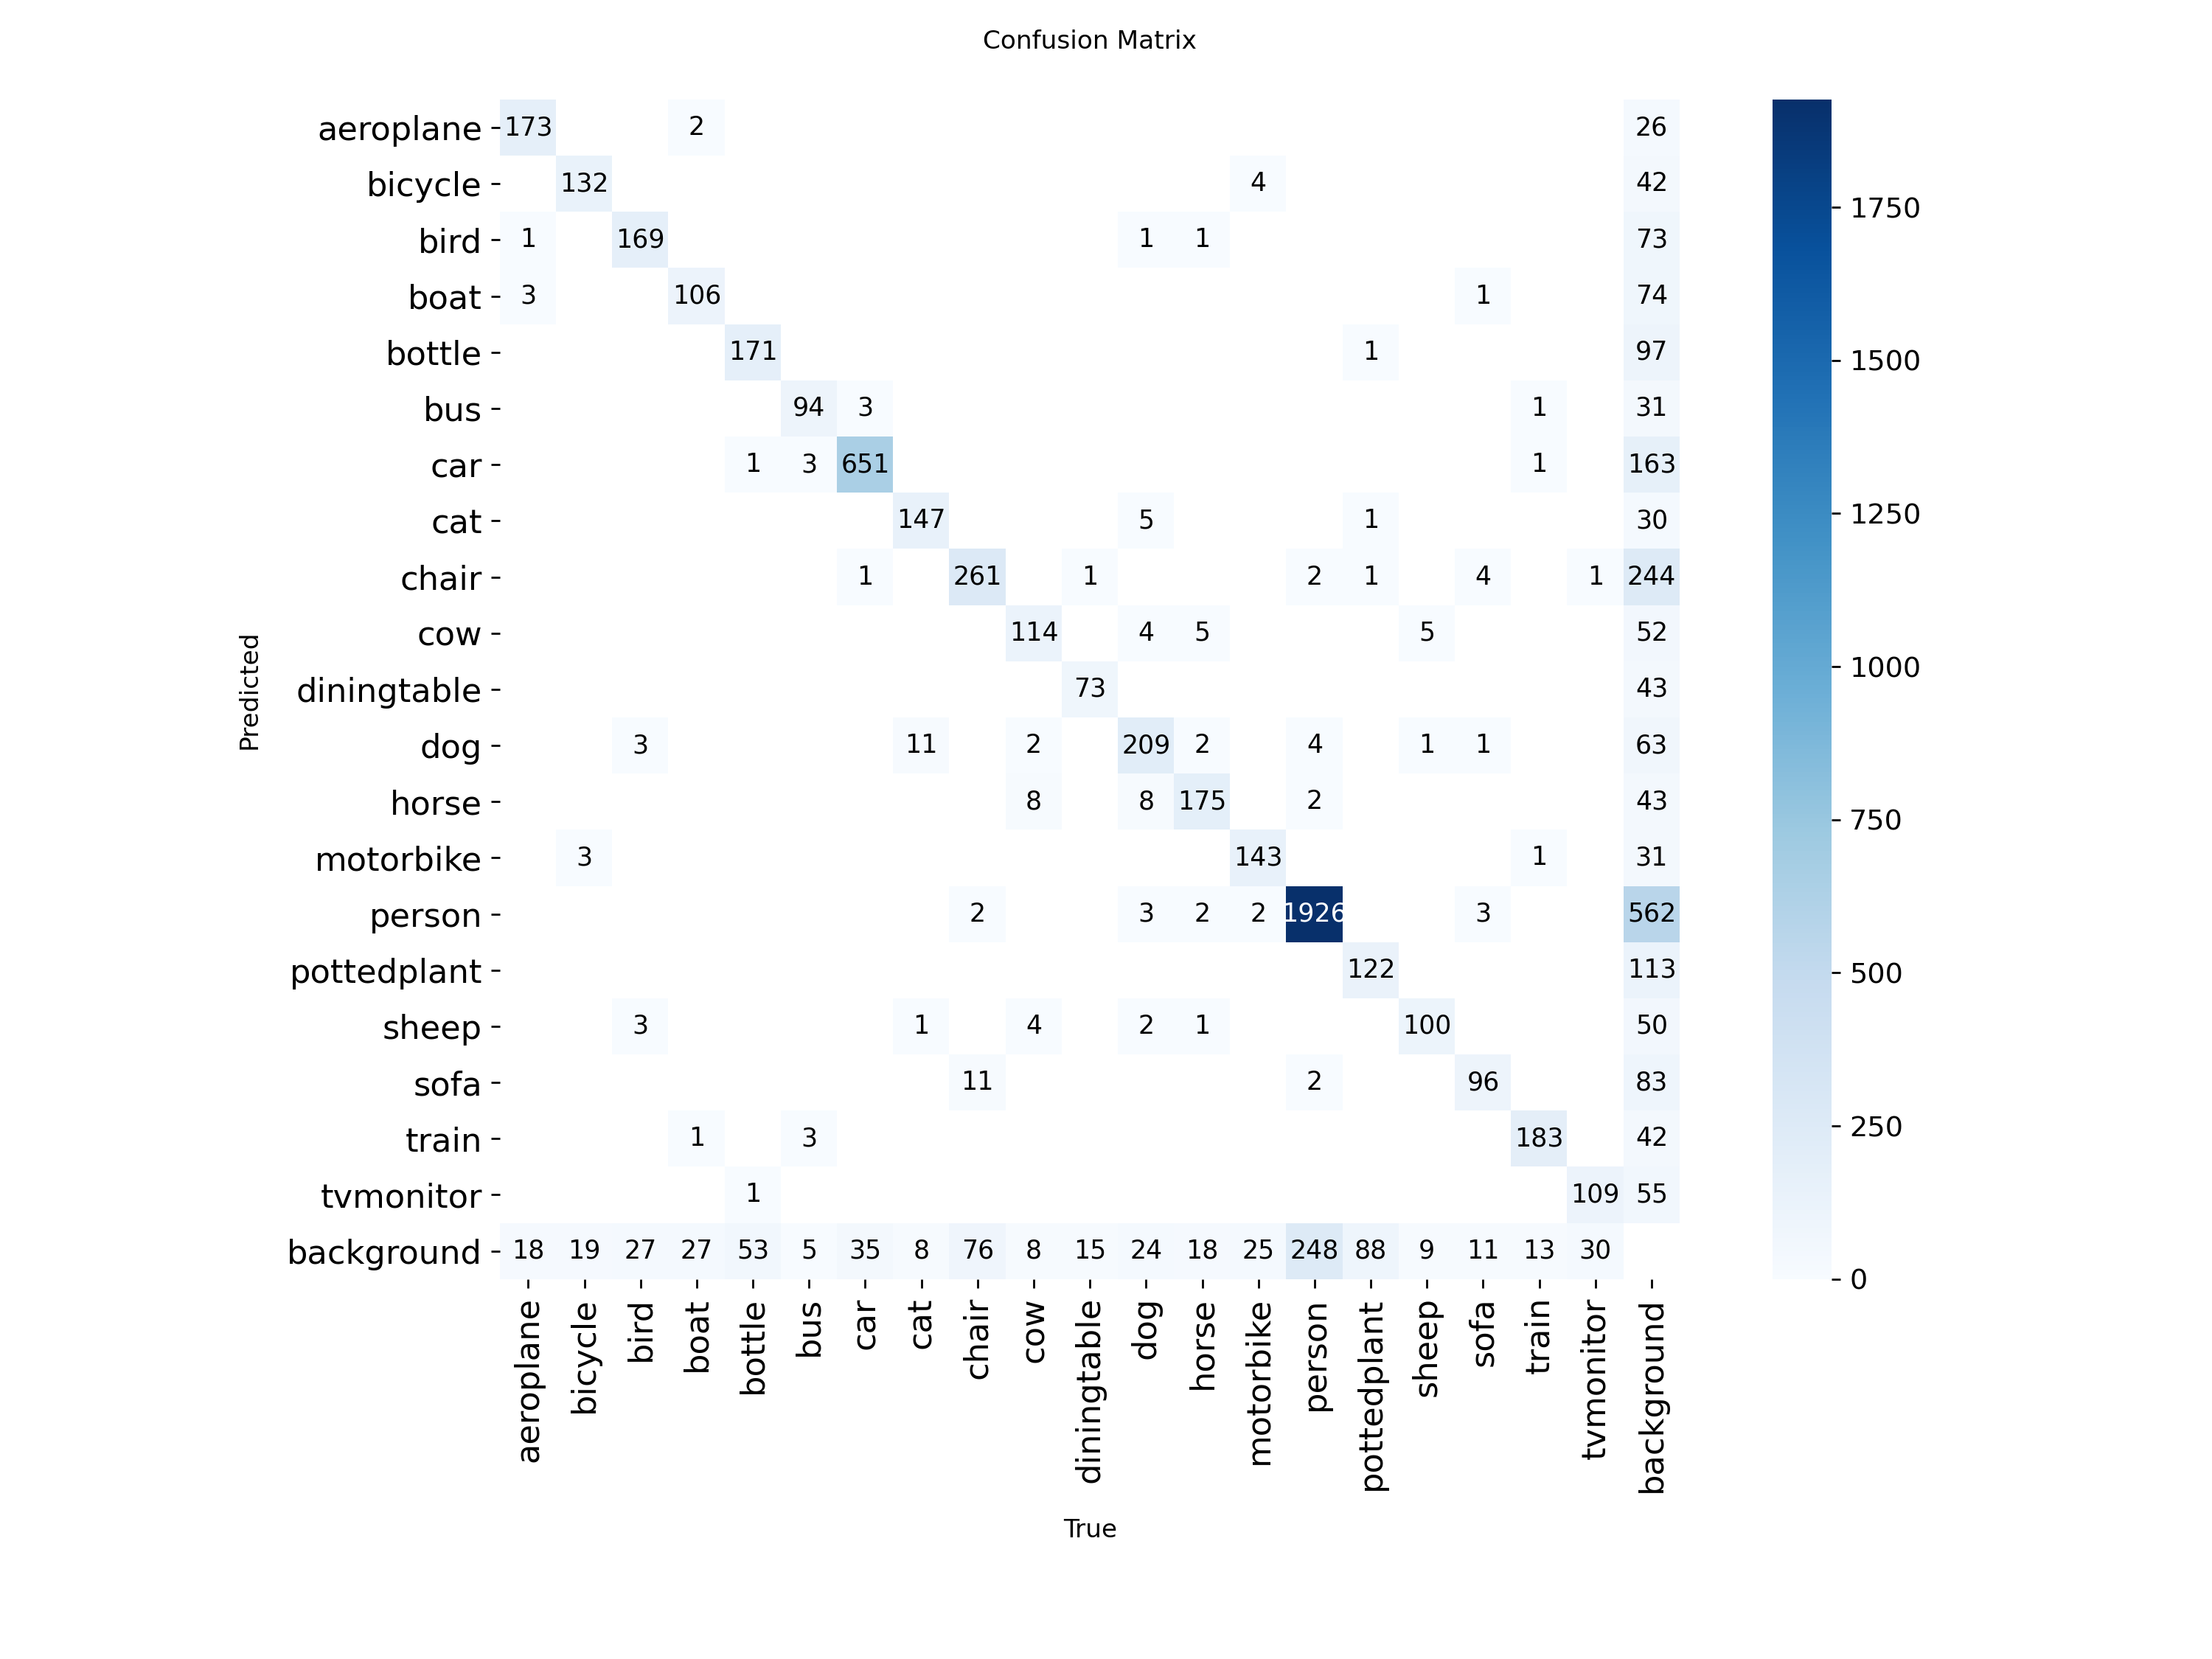

In [5]:
import os
from IPython.display import Image, display

print("\n========== END OF TRAINING METRICS ==========")

# Calculate Peak Memory Consumed across the GPUs
peak_memory_bytes = torch.cuda.max_memory_allocated()
peak_memory_gb = peak_memory_bytes / (1024 ** 3)
print(f"Total Peak GPU Memory Consumed: {peak_memory_gb:.2f} GB")

# Ultralytics automatically generates and saves the Confusion Matrix
conf_matrix_path = os.path.join(model.trainer.save_dir, 'confusion_matrix.png')

if os.path.exists(conf_matrix_path):
    print("\nConfusion Matrix for all PASCAL VOC Classes:")
    display(Image(filename=conf_matrix_path, width=800))
else:
    print("Confusion matrix image not found. Ensure training completed!")


In [6]:
import cv2
import time
from ultralytics import YOLO

# 1. Load your newly trained model
# Note: 'yolo_voc/v9_train/weights/best.pt' is where the best weights are saved based on Cell 3.
trained_model = YOLO('/kaggle/working/runs/detect/yolo_voc/v9_train/weights/best.pt')

# 2. Define the path to your uploaded video 
# (To upload to Kaggle: Click "Add Data" in the right sidebar -> "Upload" -> Select your video)
# Replace the path below with your actual uploaded video path!
video_path = '/kaggle/input/datasets/govindks/sample/Sample Video 1.mp4'  # Update this path based on where you uploaded it

# 3. Get total frames using OpenCV
cap = cv2.VideoCapture(video_path)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
original_fps = cap.get(cv2.CAP_PROP_FPS)
cap.release()

print("========== VIDEO DETECT INFO ==========")
print(f"Total Frames in Uploaded Video: {total_frames}")
print(f"Original Video FPS: {original_fps}")
print("Starting YOLOv9 Inference...\n")

# 4. Run inference on the video
# 'save=True' tells YOLO to save the final video with bounding boxes drawn.
# 'stream=True' is CRITICAL so it doesn't crash Kaggle's RAM on long videos.
results = trained_model.predict(source=video_path, save=True, stream=True)

# 5. Extract speed stats as it processes
total_preprocess = 0.0
total_inference = 0.0
total_postprocess = 0.0
processed_frames = 0

for r in results:
    total_preprocess += r.speed['preprocess']
    total_inference += r.speed['inference']
    total_postprocess += r.speed['postprocess']
    processed_frames += 1

# 6. Display final processing stats
if processed_frames > 0:
    avg_inf = total_inference / processed_frames
    avg_total = (total_preprocess + total_inference + total_postprocess) / processed_frames
    
    print("\n========== YOLOv9 PROCESSING STATS ==========")
    print(f"Total Frames Processed: {processed_frames}")
    print(f"Avg Inference Time per Frame: {avg_inf:.2f} ms")
    print(f"Avg Total Processing Time per Frame: {avg_total:.2f} ms")
    print(f"Effective Processing Speed: {(1000 / avg_total):.2f} FPS")
    print(f"\nSUCCESS! The fully annotated video is saved inside Kaggle at:")
    print(f"/kaggle/working/runs/detect/predict/")


========== VIDEO DETECT INFO ==========
Total Frames in Uploaded Video: 1239
Original Video FPS: 30.0
Starting YOLOv9 Inference...


video 1/1 (frame 1/1239) /kaggle/input/datasets/govindks/sample/Sample Video 1.mp4: 384x640 3 buss, 9 cars, 3 trains, 71.8ms
video 1/1 (frame 2/1239) /kaggle/input/datasets/govindks/sample/Sample Video 1.mp4: 384x640 2 buss, 10 cars, 1 train, 30.6ms
video 1/1 (frame 3/1239) /kaggle/input/datasets/govindks/sample/Sample Video 1.mp4: 384x640 2 buss, 11 cars, 2 trains, 30.6ms
video 1/1 (frame 4/1239) /kaggle/input/datasets/govindks/sample/Sample Video 1.mp4: 384x640 3 buss, 10 cars, 30.6ms
video 1/1 (frame 5/1239) /kaggle/input/datasets/govindks/sample/Sample Video 1.mp4: 384x640 3 buss, 11 cars, 1 train, 30.6ms
video 1/1 (frame 6/1239) /kaggle/input/datasets/govindks/sample/Sample Video 1.mp4: 384x640 3 buss, 11 cars, 1 train, 30.6ms
video 1/1 (frame 7/1239) /kaggle/input/datasets/govindks/sample/Sample Video 1.mp4: 384x640 2 buss, 10 cars, 1 train, 30.6ms


In [7]:
import cv2
import time
from ultralytics import YOLO

# 1. Load your newly trained model
# Note: 'yolo_voc/v9_train/weights/best.pt' is where the best weights are saved based on Cell 3.
trained_model = YOLO('/kaggle/working/runs/detect/yolo_voc/v9_train/weights/best.pt')

# 2. Define the path to your uploaded video 
# (To upload to Kaggle: Click "Add Data" in the right sidebar -> "Upload" -> Select your video)
# Replace the path below with your actual uploaded video path!
video_path = '/kaggle/input/datasets/govindks/sample/Sample Video 2.mp4'  # Update this path based on where you uploaded it

# 3. Get total frames using OpenCV
cap = cv2.VideoCapture(video_path)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
original_fps = cap.get(cv2.CAP_PROP_FPS)
cap.release()

print("========== VIDEO DETECT INFO ==========")
print(f"Total Frames in Uploaded Video: {total_frames}")
print(f"Original Video FPS: {original_fps}")
print("Starting YOLOv9 Inference...\n")

# 4. Run inference on the video
# 'save=True' tells YOLO to save the final video with bounding boxes drawn.
# 'stream=True' is CRITICAL so it doesn't crash Kaggle's RAM on long videos.
results = trained_model.predict(source=video_path, save=True, stream=True)

# 5. Extract speed stats as it processes
total_preprocess = 0.0
total_inference = 0.0
total_postprocess = 0.0
processed_frames = 0

for r in results:
    total_preprocess += r.speed['preprocess']
    total_inference += r.speed['inference']
    total_postprocess += r.speed['postprocess']
    processed_frames += 1

# 6. Display final processing stats
if processed_frames > 0:
    avg_inf = total_inference / processed_frames
    avg_total = (total_preprocess + total_inference + total_postprocess) / processed_frames
    
    print("\n========== YOLOv9 PROCESSING STATS ==========")
    print(f"Total Frames Processed: {processed_frames}")
    print(f"Avg Inference Time per Frame: {avg_inf:.2f} ms")
    print(f"Avg Total Processing Time per Frame: {avg_total:.2f} ms")
    print(f"Effective Processing Speed: {(1000 / avg_total):.2f} FPS")
    print(f"\nSUCCESS! The fully annotated video is saved inside Kaggle at:")
    print(f"/kaggle/working/runs/detect/predict/")


========== VIDEO DETECT INFO ==========
Total Frames in Uploaded Video: 714
Original Video FPS: 30.0
Starting YOLOv9 Inference...


video 1/1 (frame 1/714) /kaggle/input/datasets/govindks/sample/Sample Video 2.mp4: 384x640 (no detections), 30.8ms
video 1/1 (frame 2/714) /kaggle/input/datasets/govindks/sample/Sample Video 2.mp4: 384x640 (no detections), 29.9ms
video 1/1 (frame 3/714) /kaggle/input/datasets/govindks/sample/Sample Video 2.mp4: 384x640 (no detections), 26.8ms
video 1/1 (frame 4/714) /kaggle/input/datasets/govindks/sample/Sample Video 2.mp4: 384x640 (no detections), 21.8ms
video 1/1 (frame 5/714) /kaggle/input/datasets/govindks/sample/Sample Video 2.mp4: 384x640 (no detections), 21.9ms
video 1/1 (frame 6/714) /kaggle/input/datasets/govindks/sample/Sample Video 2.mp4: 384x640 (no detections), 21.4ms
video 1/1 (frame 7/714) /kaggle/input/datasets/govindks/sample/Sample Video 2.mp4: 384x640 (no detections), 21.4ms
video 1/1 (frame 8/714) /kaggle/input/datasets/govindks/sample/

In [8]:
import pandas as pd
import os
import glob
from IPython.display import display

print("========== PRESENTATION METRICS PER EPOCH ==========")

# If you ran training multiple times, YOLO adds numbers to the folder (v9_train2, v9_train3).
# So instead of guessing, we forcefully search the hard drive for the newest 'results.csv' file!
found_files = glob.glob('/kaggle/working/**/results.csv', recursive=True) + glob.glob('./**/results.csv', recursive=True)

if found_files:
    # Grab the most recently modified results file we can find
    newest_results_path = max(found_files, key=os.path.getmtime)
    print(f"(Reading data from: {newest_results_path})\n")
    
    df = pd.read_csv(newest_results_path)
    df.columns = df.columns.str.strip()
    
    # Reconstruct the exact presentation table!
    presentation_df = pd.DataFrame()
    presentation_df['Epoch'] = df['epoch']
    presentation_df['Training Loss'] = df['train/box_loss'] + df['train/cls_loss'] + df['train/dfl_loss']
    presentation_df['Validation Loss'] = df['val/box_loss'] + df['val/cls_loss'] + df['val/dfl_loss']
    presentation_df['mAP@50 (Mean IoU)'] = df['metrics/mAP50(B)']
    
    # Render the gorgeous HTML table
    display(presentation_df.round(4))
else:
    print("Could not find any results.csv anywhere. Did the training crash before completing Epoch 1?")


========== PRESENTATION METRICS PER EPOCH ==========
(Reading data from: /kaggle/working/runs/detect/yolo_voc/v9_train/results.csv)



,Epoch,Training Loss,Validation Loss,mAP@50 (Mean IoU)
0,1,12.1856,9.8251,0.0073
1,2,8.1003,6.9010,0.1297
2,3,6.4706,6.5101,0.1638
3,4,5.8455,5.5947,0.2921
4,5,5.3356,5.3072,0.3741
5,6,4.9805,4.6606,0.4702
6,7,4.7338,4.4176,0.5350
7,8,4.5372,4.1313,0.5866
8,9,4.4047,4.0285,0.6123
9,10,4.2966,3.8856,0.6514


========== GENERATING PRESENTATION VISUALS ==========


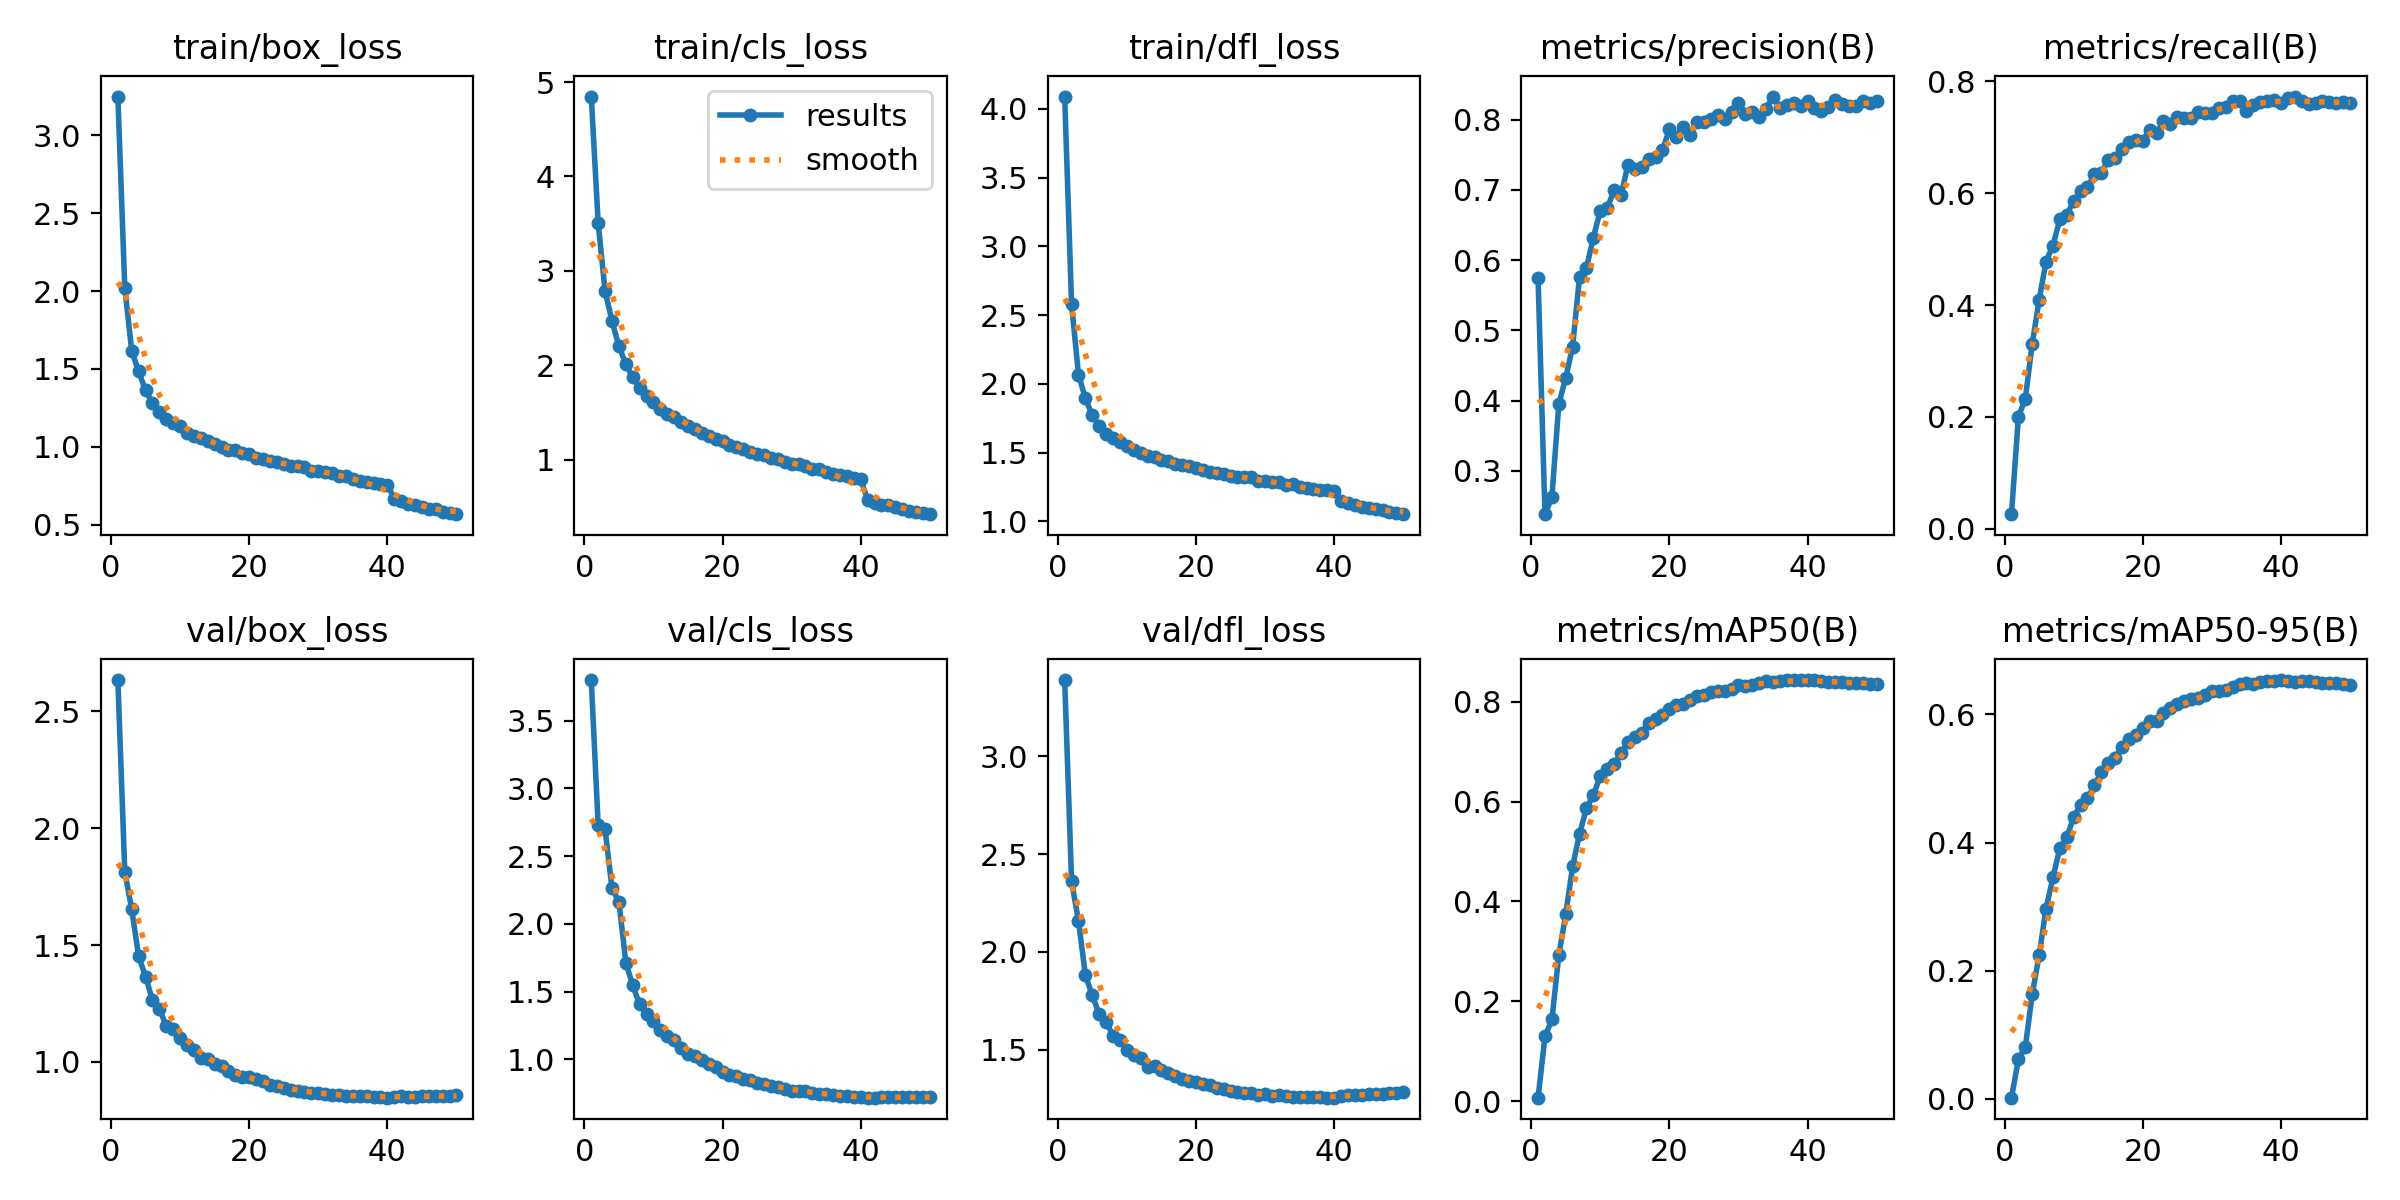

Could not find F1_curve.png
Could not find PR_curve.png


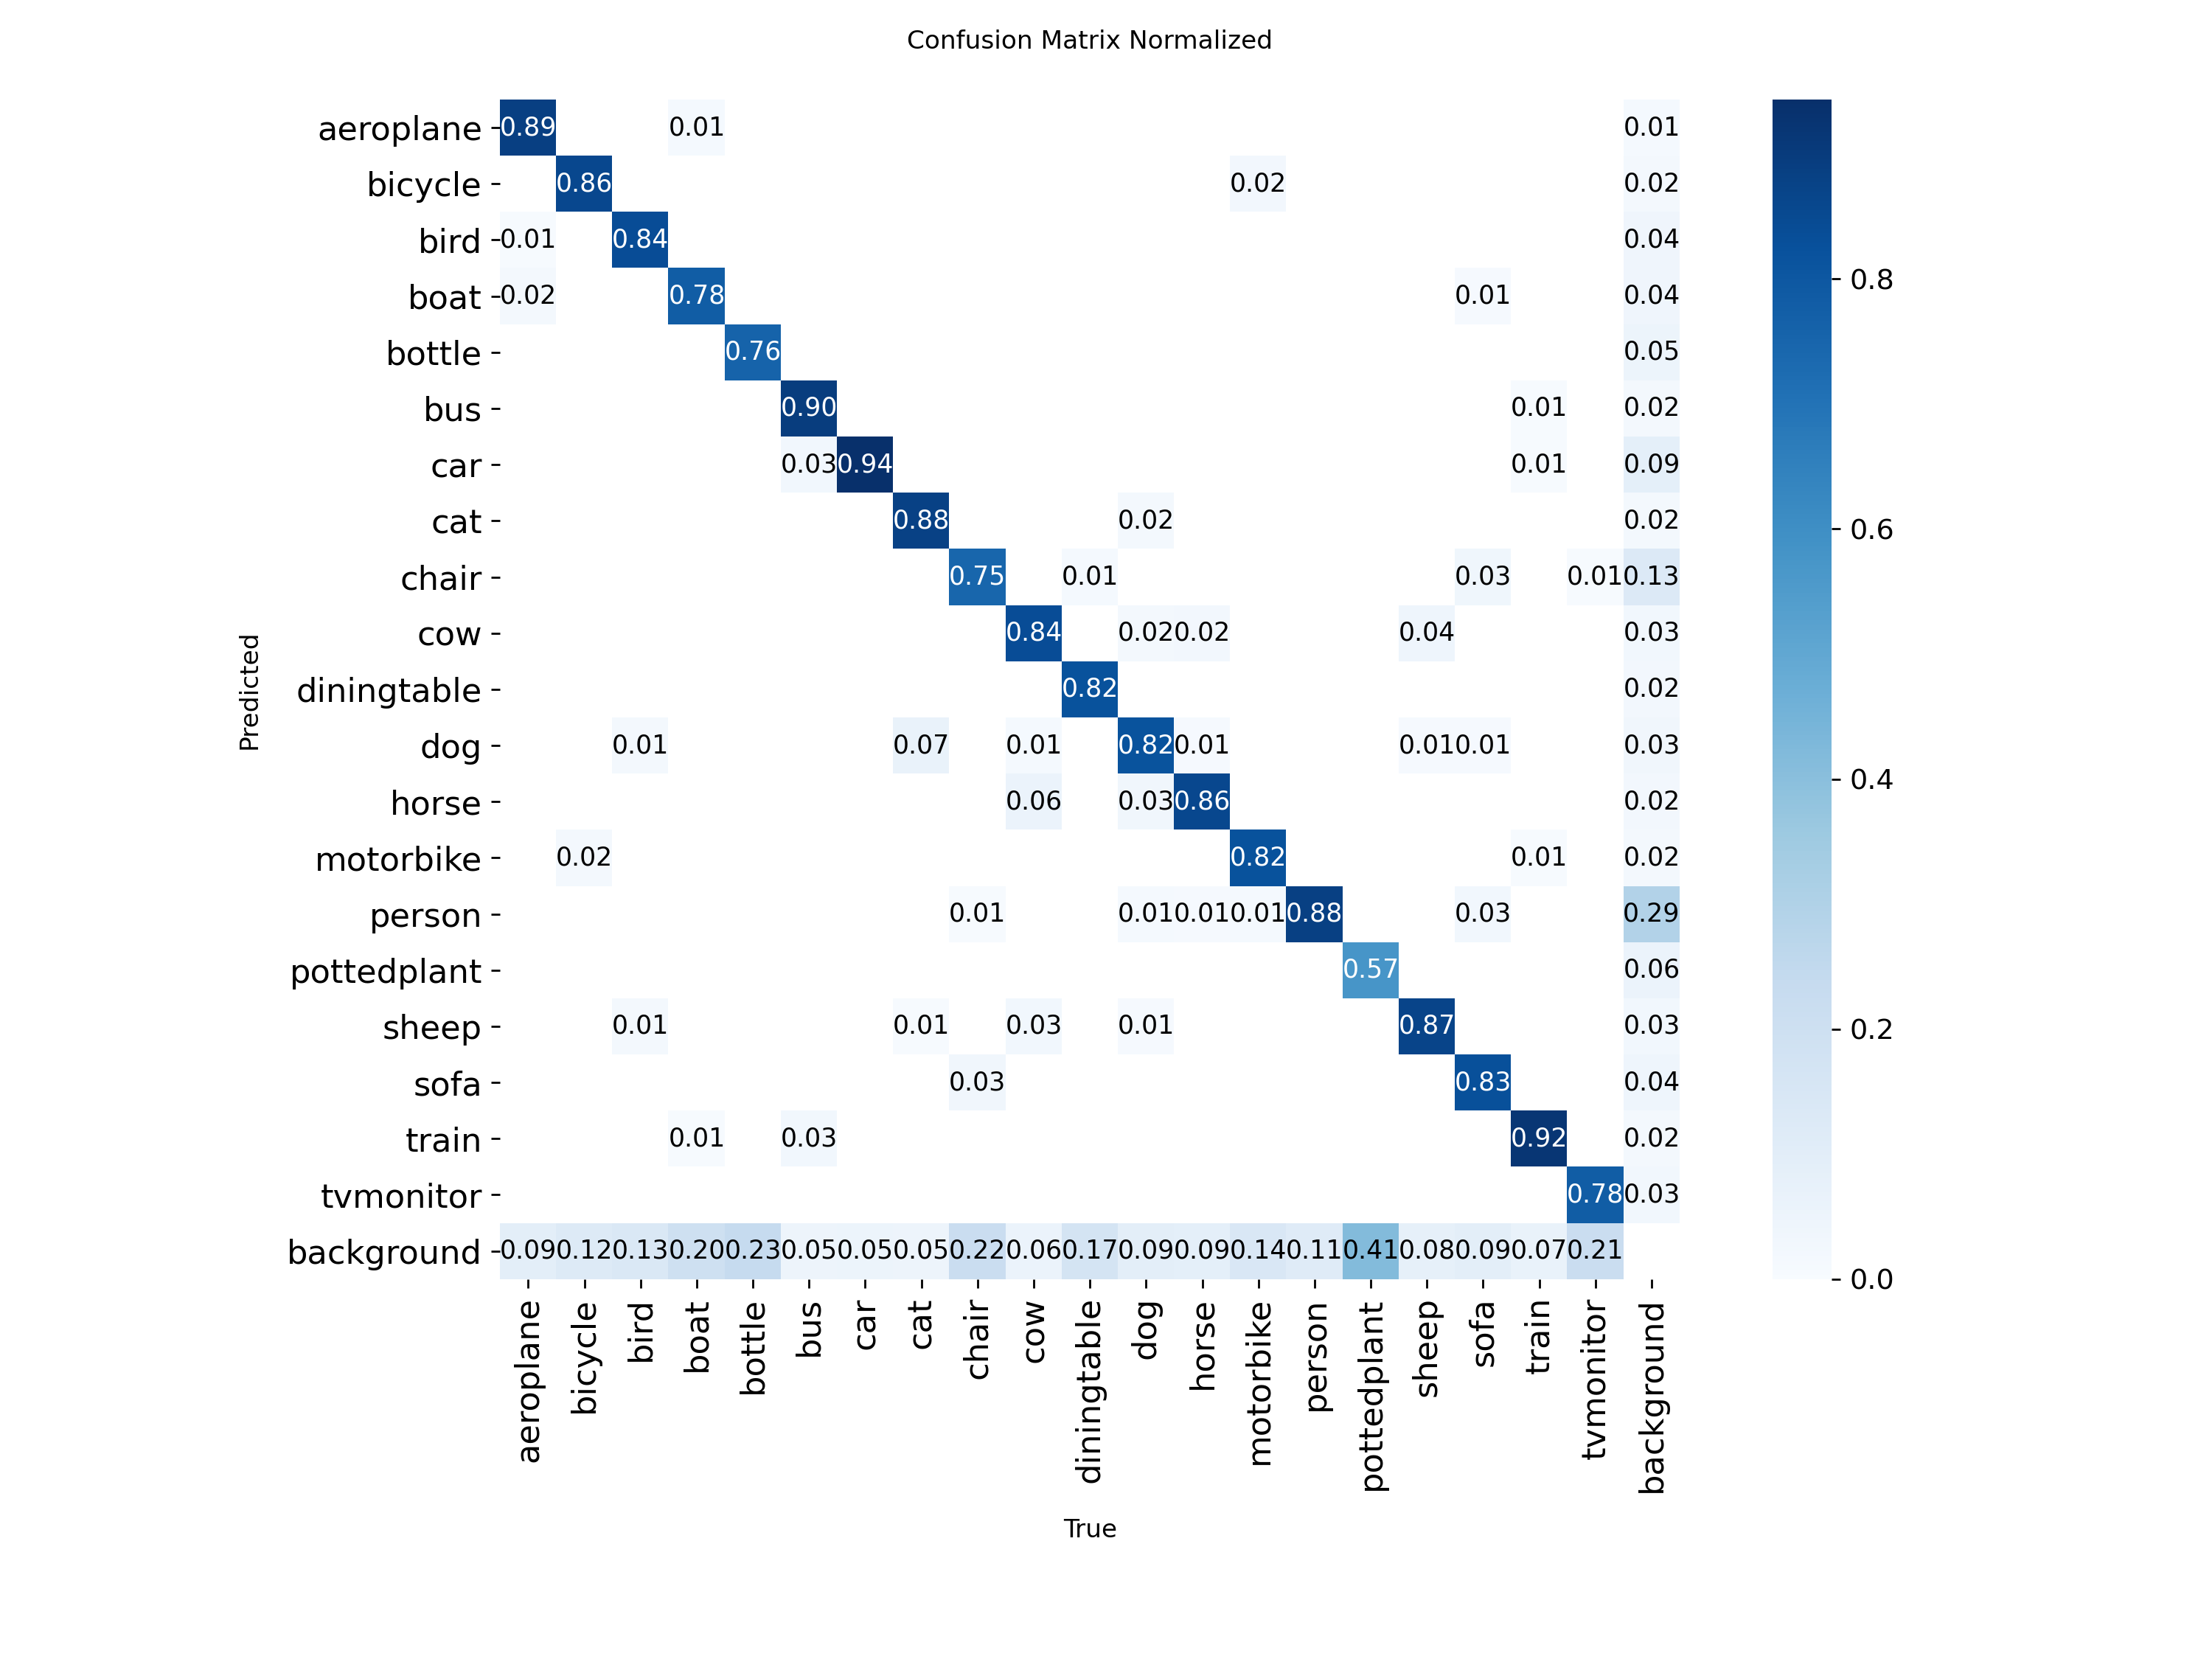

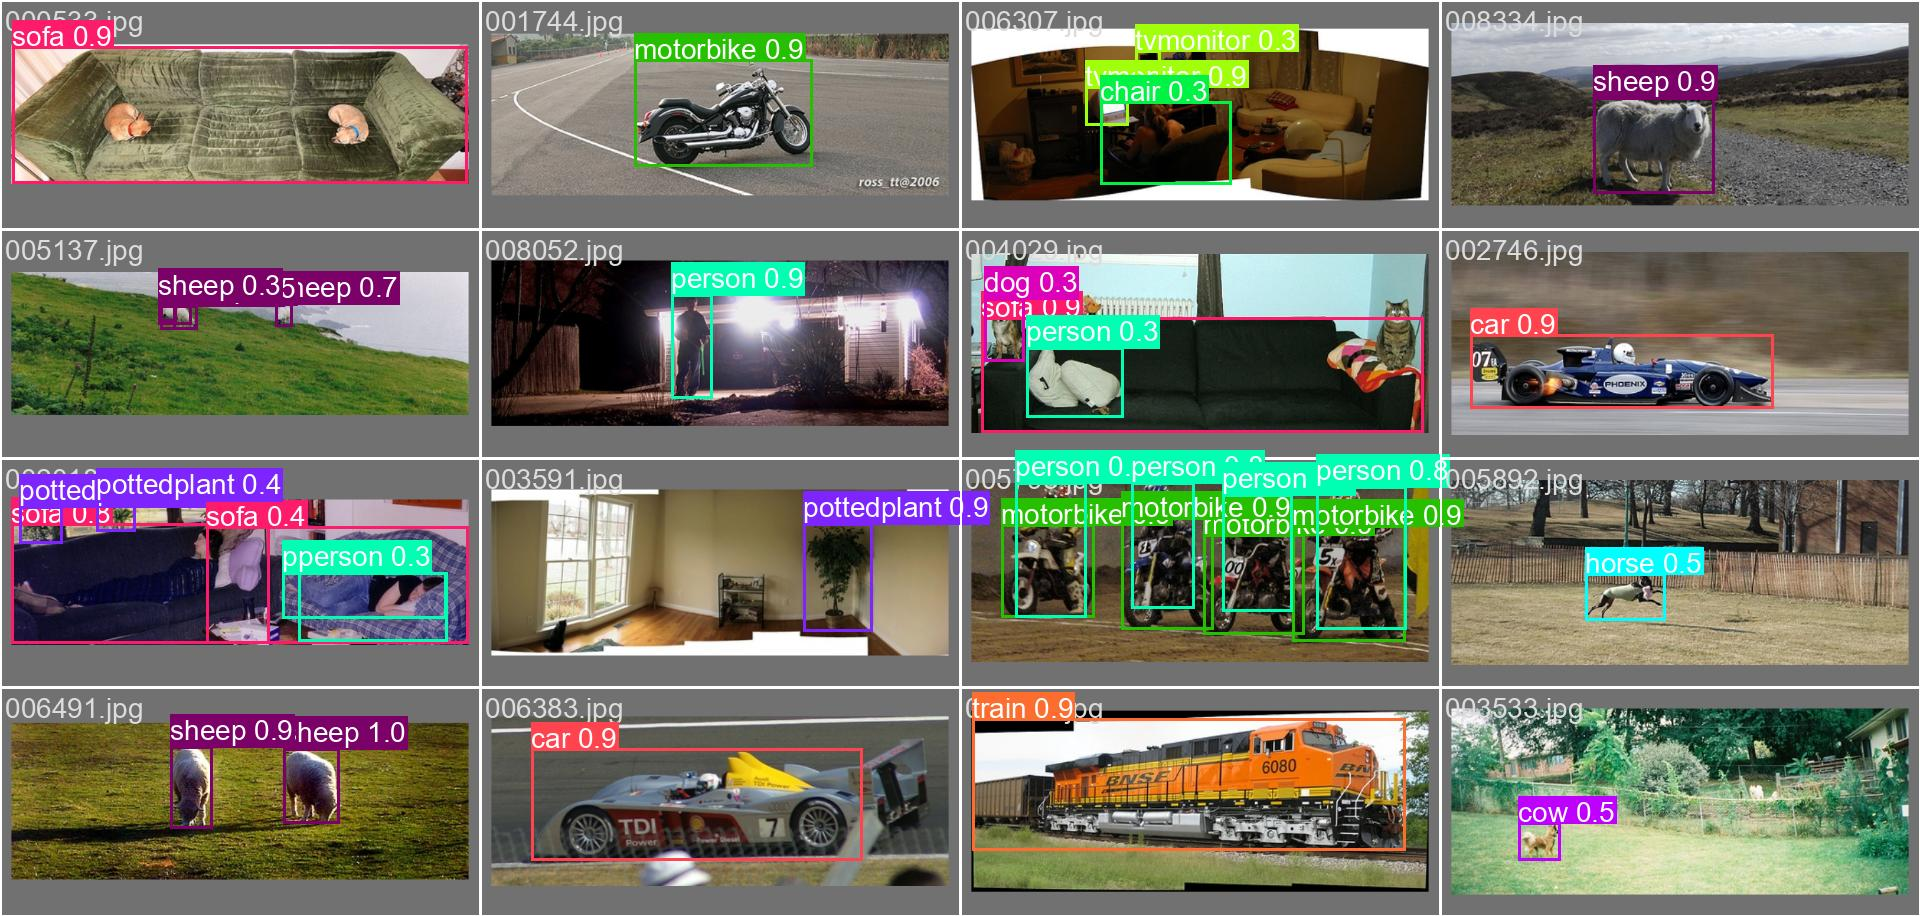

In [9]:
import glob
import os
from IPython.display import Image, display, HTML

print("========== GENERATING PRESENTATION VISUALS ==========")

# Find the newest train directory where YOLO saved all the glorious auto-graphs
found_dirs = glob.glob('/kaggle/working/**/weights', recursive=True) + glob.glob('./**/weights', recursive=True)

if found_dirs:
    # Get the parent directory of the newest 'weights' folder
    latest_run_dir = os.path.dirname(max(found_dirs, key=os.path.getmtime))
    
    # List of high-impact research graphs we want to show your sir
    graphs_to_show = [
        ("1. The Learning Journey (Loss & mAP Curves)", 'results.png', 1000),
        ("2. The Accuracy Frontier (F1-Confidence Curve)", 'F1_curve.png', 800),
        ("3. Precision-Recall Tradeoff", 'PR_curve.png', 800),
        ("4. Where it struggles (Normalized Confusion Matrix)", 'confusion_matrix_normalized.png', 800),
        ("5. The Eye Test (Real Validation Predictions)", 'val_batch0_pred.jpg', 1000)
    ]
    
    for title, filename, width in graphs_to_show:
        img_path = os.path.join(latest_run_dir, filename)
        if os.path.exists(img_path):
            display(HTML(f"<h3 style='color: #2e86c1; margin-top:30px;'>{title}</h3>"))
            display(Image(filename=img_path, width=width))
        else:
            print(f"Could not find {filename}")
else:
    print("Could not locate the YOLO run directory.")


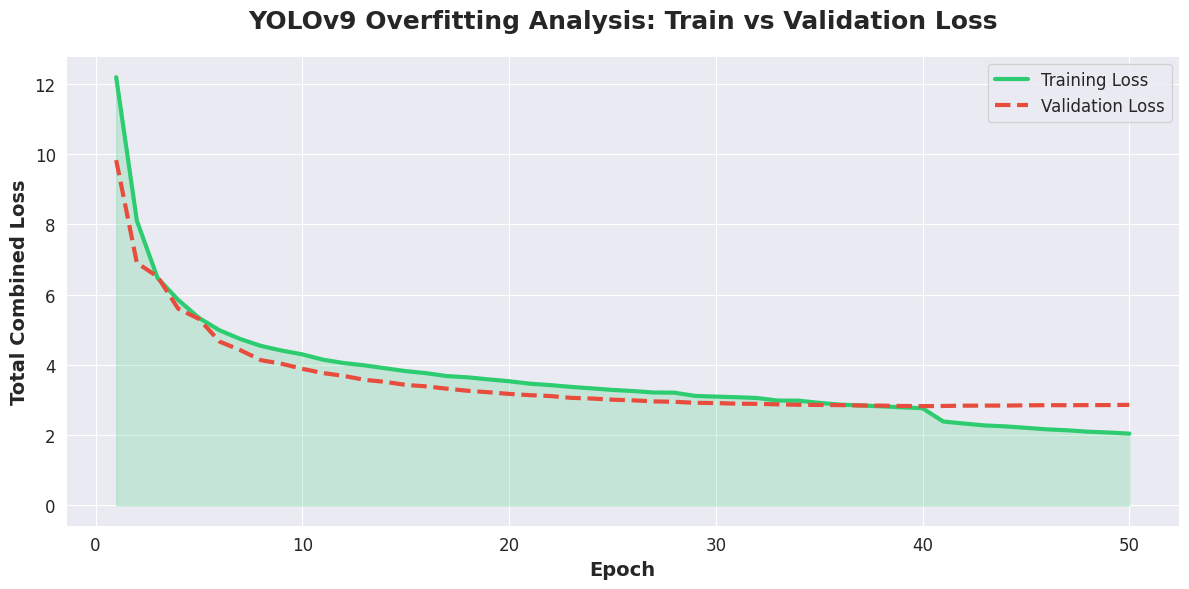


SUCCESS! HD Graph saved as 'custom_overfitting_analysis.png'. Download it and put it in your slides!


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# 1. Find the newest results.csv
results_files = glob.glob('/kaggle/working/**/results.csv', recursive=True) + glob.glob('./**/results.csv', recursive=True)
latest_csv = max(results_files, key=os.path.getmtime)
df = pd.read_csv(latest_csv)
df.columns = df.columns.str.strip()

# 2. Extract Data
epochs = df['epoch']
# Total Train Loss = Box + Class + DFL
train_loss = df['train/box_loss'] + df['train/cls_loss'] + df['train/dfl_loss']
# Total Val Loss = Box + Class + DFL
val_loss = df['val/box_loss'] + df['val/cls_loss'] + df['val/dfl_loss']

# 3. Create a beautiful, presentation-ready graph
plt.figure(figsize=(12, 6))
sns.set_style("darkgrid")

# Plot Train Loss with a blue shaded area
plt.plot(epochs, train_loss, label='Training Loss', color='#2ecc71', linewidth=3)
plt.fill_between(epochs, train_loss, alpha=0.2, color='#2ecc71')

# Plot Validation Loss with a red shaded area
plt.plot(epochs, val_loss, label='Validation Loss', color='#e74c3c', linewidth=3, linestyle='--')

# Styling
plt.title("YOLOv9 Overfitting Analysis: Train vs Validation Loss", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Epoch", fontsize=14, fontweight='bold')
plt.ylabel("Total Combined Loss", fontsize=14, fontweight='bold')
plt.legend(fontsize=12, loc='upper right')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Make axes thicker
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# Save and show!
plt.tight_layout()
plt.savefig('custom_overfitting_analysis.png', dpi=300) # Saves an ultra-HD version for your PPT
plt.show()

print("\nSUCCESS! HD Graph saved as 'custom_overfitting_analysis.png'. Download it and put it in your slides!")


In [11]:
import cv2
import time
from ultralytics import YOLO

# 1. Load your newly trained model
# Note: 'yolo_voc/v9_train/weights/best.pt' is where the best weights are saved based on Cell 3.
trained_model = YOLO('/kaggle/working/runs/detect/yolo_voc/v9_train/weights/best.pt')

# 2. Define the path to your uploaded video 
# (To upload to Kaggle: Click "Add Data" in the right sidebar -> "Upload" -> Select your video)
# Replace the path below with your actual uploaded video path!
video_path = '/kaggle/input/datasets/govindks/sample-video-3'  # Update this path based on where you uploaded it

# 3. Get total frames using OpenCV
cap = cv2.VideoCapture(video_path)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
original_fps = cap.get(cv2.CAP_PROP_FPS)
cap.release()

print("========== VIDEO DETECT INFO ==========")
print(f"Total Frames in Uploaded Video: {total_frames}")
print(f"Original Video FPS: {original_fps}")
print("Starting YOLOv9 Inference...\n")

# 4. Run inference on the video
# 'save=True' tells YOLO to save the final video with bounding boxes drawn.
# 'stream=True' is CRITICAL so it doesn't crash Kaggle's RAM on long videos.
results = trained_model.predict(source=video_path, save=True, stream=True)

# 5. Extract speed stats as it processes
total_preprocess = 0.0
total_inference = 0.0
total_postprocess = 0.0
processed_frames = 0

for r in results:
    total_preprocess += r.speed['preprocess']
    total_inference += r.speed['inference']
    total_postprocess += r.speed['postprocess']
    processed_frames += 1

# 6. Display final processing stats
if processed_frames > 0:
    avg_inf = total_inference / processed_frames
    avg_total = (total_preprocess + total_inference + total_postprocess) / processed_frames
    
    print("\n========== YOLOv9 PROCESSING STATS ==========")
    print(f"Total Frames Processed: {processed_frames}")
    print(f"Avg Inference Time per Frame: {avg_inf:.2f} ms")
    print(f"Avg Total Processing Time per Frame: {avg_total:.2f} ms")
    print(f"Effective Processing Speed: {(1000 / avg_total):.2f} FPS")
    print(f"\nSUCCESS! The fully annotated video is saved inside Kaggle at:")
    print(f"/kaggle/working/runs/detect/predict/")


========== VIDEO DETECT INFO ==========
Total Frames in Uploaded Video: 0
Original Video FPS: 0.0
Starting YOLOv9 Inference...




FileNotFoundError: /kaggle/input/datasets/govindks/sample-video-3 does not exist

In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO
from IPython.display import clear_output

# 1. Load your trained model
trained_model = YOLO('/kaggle/working/runs/detect/yolo_voc/v9_train/weights/best.pt')

# 2. Paths (Change video_path to your actual video)
video_path = '/kaggle/input/datasets/govindks/sample/Sample Video 1.mp4'
output_path = '/kaggle/working/spicy_tracking_video-1.mp4'

cap = cv2.VideoCapture(video_path)
w, h, fps = (int(cap.get(x)) for x in (cv2.CAP_PROP_FRAME_WIDTH, cv2.CAP_PROP_FRAME_HEIGHT, cv2.CAP_PROP_FPS))

# Setup Video Writer
out = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))

print("🔥 Initiating Spicy ByteTrack Surveillance Mode 🔥...")

# 3. Run Inference WITH TRACKING ENABLED
# By calling .track() instead of .predict(), YOLOv9 automatically attaches ByteTrack algorithms!
results = trained_model.track(source=video_path, stream=True, tracker="bytetrack.yaml")

# Dictionary to store the history of movement for each unique ID
track_history = {}

for r in results:
    frame = r.orig_img.copy()
    
    # Are there any boxes detected in this frame?
    if r.boxes.id is not None:
        boxes = r.boxes.xywh.cpu().numpy()  # x center, y center, width, height
        track_ids = r.boxes.id.int().cpu().tolist()
        
        # Plot standard boxes
        frame = r.plot()
        
        # Draw the neon trails!
        for box, track_id in zip(boxes, track_ids):
            x, y, w_box, h_box = box
            
            # Store the bottom-center point of the object for the trail
            track = track_history.get(track_id, [])
            track.append((float(x), float(y + h_box/2)))
            if len(track) > 90:  # Keep trail length to last 90 frames (~3 seconds)
                track.pop(0)
            track_history[track_id] = track
            
            # Draw the neon line
            points = np.array(track, dtype=np.int32).reshape((-1, 1, 2))
            cv2.polylines(frame, [points], isClosed=False, color=(0, 255, 255), thickness=4) # Cyan Trail

    out.write(frame)

cap.release()
out.release()
clear_output()
print("✅ Spicy Tracking Video Saved! Download 'spicy_tracking_video.mp4' from the working directory.")
